In [3]:
#importinng all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [4]:
#Load Dataset
df = pd.read_csv("train.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [5]:
#basic operstions
print(df.shape)
print(df.info())
print(df.describe())

(381109, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB
None
                  id            Age  Driving_License    Region_Code  \
count  38

In [6]:
#Check Missing Values
print(df.isnull().sum())
df.dropna(inplace=True)

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64


In [7]:
# EDA 

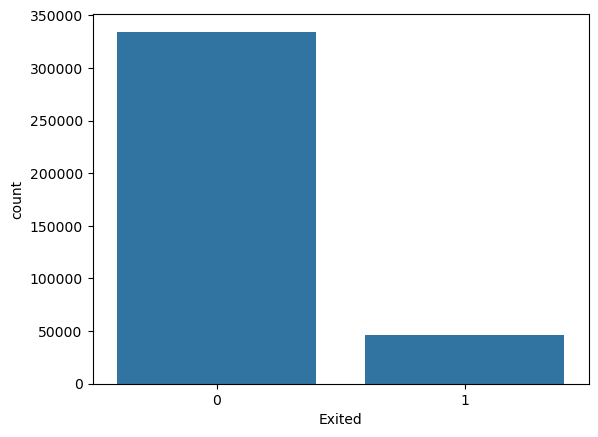

In [8]:
# churn distribution
df.columns = df.columns.str.strip()

if 'Exited' not in df.columns:
    if 'Response' in df.columns:
        df.rename(columns={'Response': 'Exited'}, inplace=True)

sns.countplot(x='Exited', data=df)
plt.show()

In [9]:
print(df.columns)

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Exited'],
      dtype='object')


In [10]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Exited'],
      dtype='object')

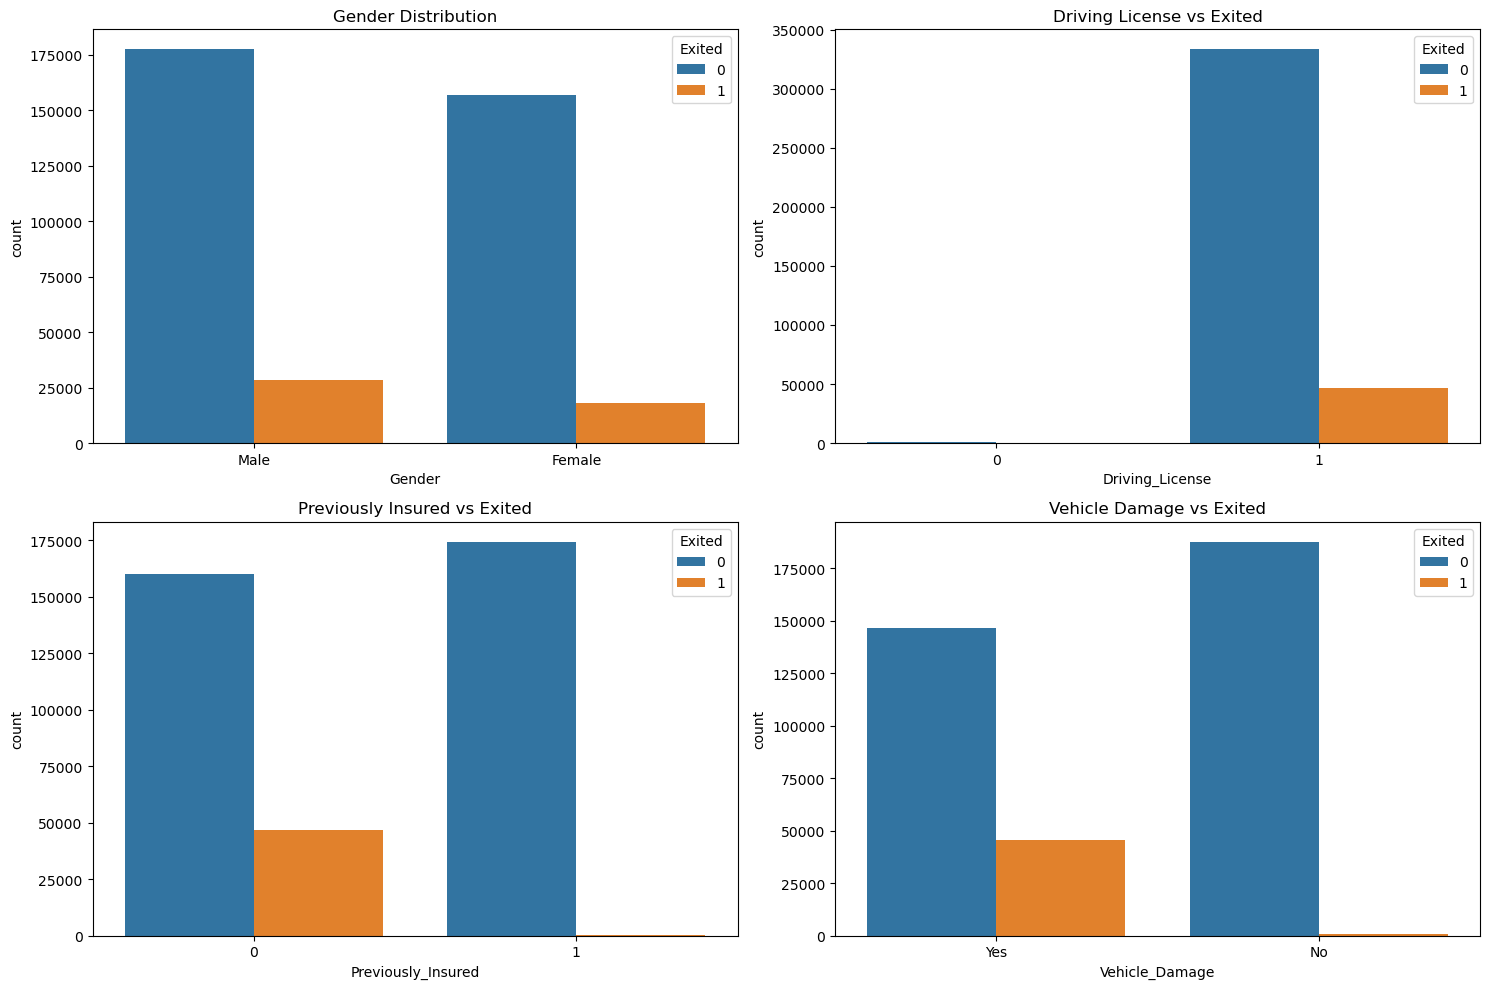

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Gender Distribution
sns.countplot(x='Gender', data=df, hue='Exited', ax=ax[0,0])
ax[0,0].set_title('Gender Distribution')

# Driving License
sns.countplot(x='Driving_License', data=df, hue='Exited', ax=ax[0,1])
ax[0,1].set_title('Driving License vs Exited')

# Previously Insured
sns.countplot(x='Previously_Insured', data=df, hue='Exited', ax=ax[1,0])
ax[1,0].set_title('Previously Insured vs Exited')

# Vehicle Damage
sns.countplot(x='Vehicle_Damage', data=df, hue='Exited', ax=ax[1,1])
ax[1,1].set_title('Vehicle Damage vs Exited')

plt.tight_layout()
plt.show()

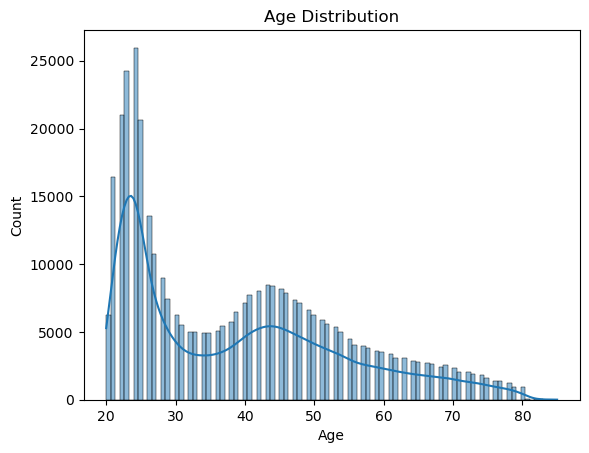

In [12]:
# age distrubution
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

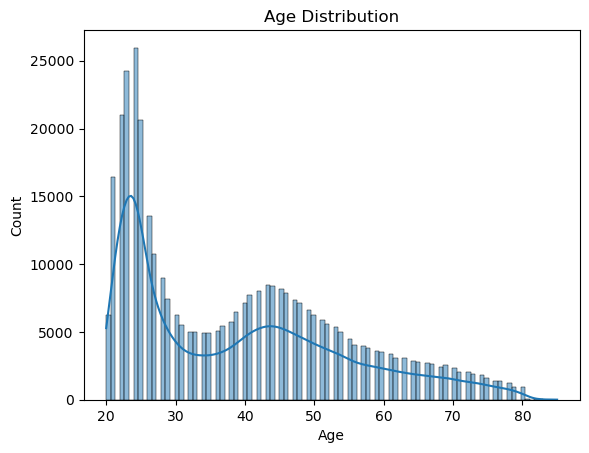

In [13]:
# claims and churn
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

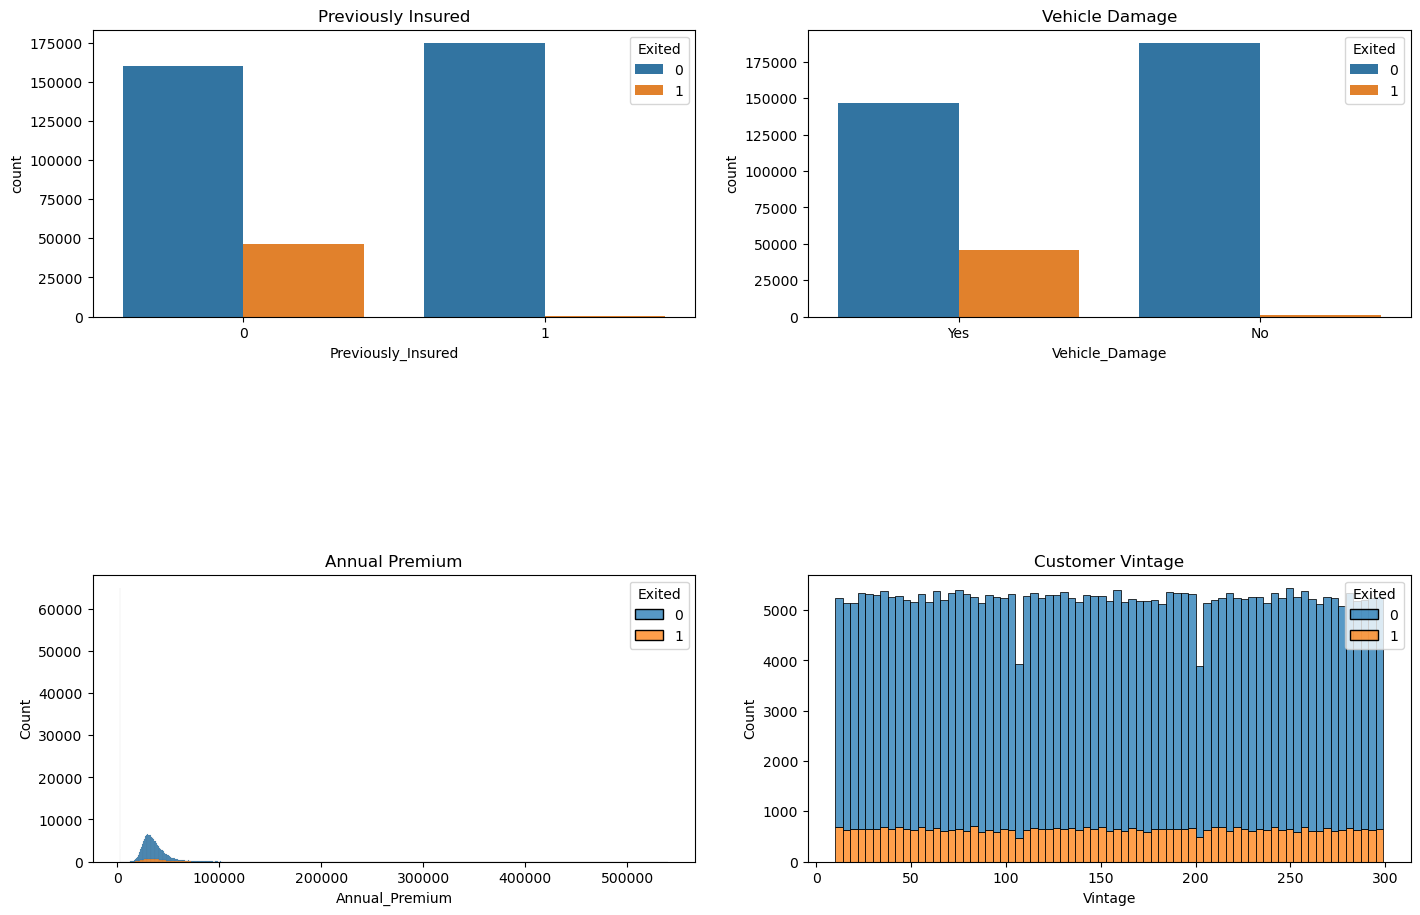

In [14]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout(pad=5.0)
fig.subplots_adjust(hspace=0.9)

# Previously Insured
sns.countplot(x='Previously_Insured', data=df, hue='Exited', ax=ax[0,0])
ax[0,0].set_title('Previously Insured')

# Vehicle Damage
sns.countplot(x='Vehicle_Damage', data=df, hue='Exited', ax=ax[0,1])
ax[0,1].set_title('Vehicle Damage')

# Annual Premium
sns.histplot(x='Annual_Premium', data=df, hue='Exited', multiple='stack', ax=ax[1,0])
ax[1,0].set_title('Annual Premium')

# Vintage
sns.histplot(x='Vintage', data=df, hue='Exited', multiple='stack', ax=ax[1,1])
ax[1,1].set_title('Customer Vintage')

plt.show()

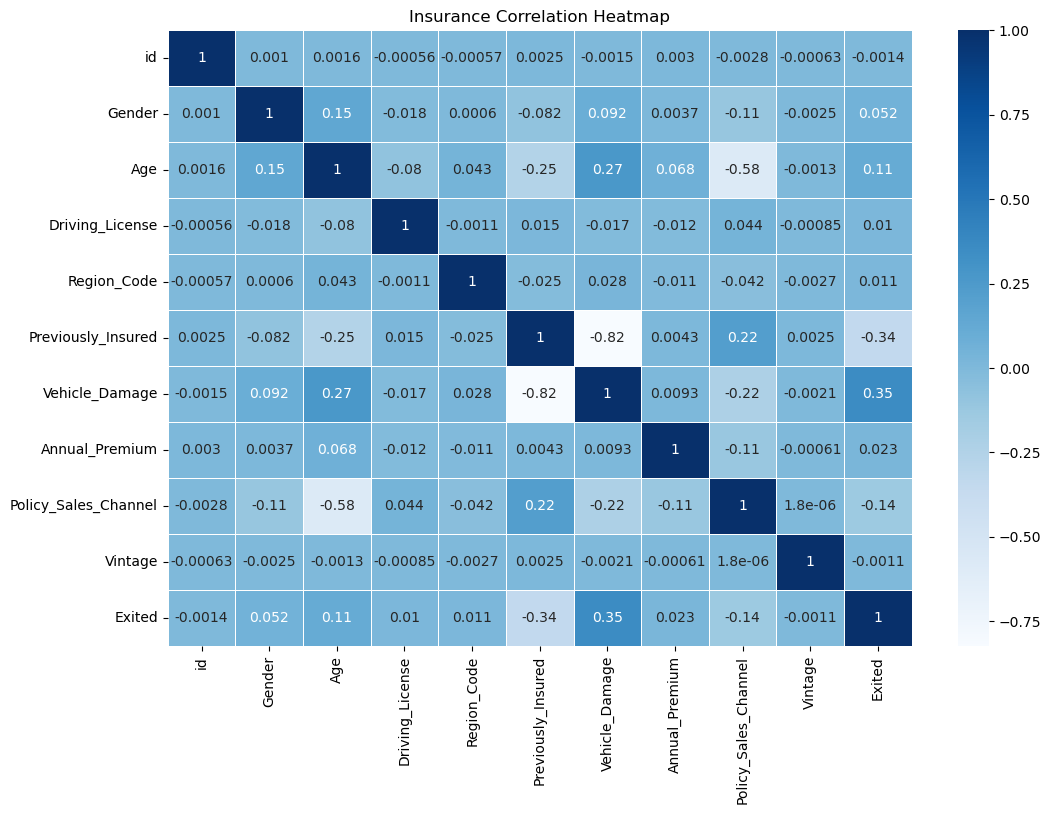

In [15]:
# Convert needed categorical columns
df_corr = df.copy()
df_corr['Gender'] = df_corr['Gender'].map({'Male':1, 'Female':0})
df_corr['Vehicle_Damage'] = df_corr['Vehicle_Damage'].map({'Yes':1, 'No':0})

# Take only numeric columns
corr = df_corr.select_dtypes(include=['number']).corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='Blues', linewidths=0.5)

plt.title("Insurance Correlation Heatmap")
plt.show()

In [16]:
# Encoding Categorical Variables
df = pd.get_dummies(df, drop_first=True)

In [17]:
# Feature & Target Split
X = df.drop('Exited', axis=1)
y = df['Exited']

In [18]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
print("Training started...")

model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)

print("Training completed!")

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Training started...
Training completed!
Accuracy: 0.8683057385006954


In [21]:
# classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93     66880
           1       0.38      0.11      0.17      9342

    accuracy                           0.87     76222
   macro avg       0.63      0.54      0.55     76222
weighted avg       0.82      0.87      0.84     76222



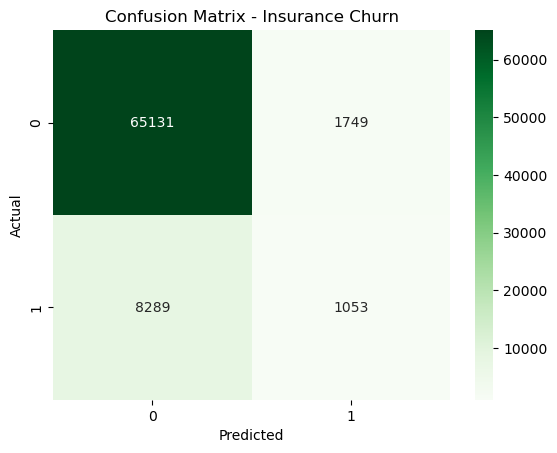

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Insurance Churn")
plt.show()

In [23]:
# ROC-AUC Score
y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8019928257514296


In [24]:
#Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(10))

                 Feature  Importance
0                     id    0.208279
7                Vintage    0.191800
5         Annual_Premium    0.171621
1                    Age    0.126455
3            Region_Code    0.089322
4     Previously_Insured    0.075922
6   Policy_Sales_Channel    0.057583
11    Vehicle_Damage_Yes    0.051168
9   Vehicle_Age_< 1 Year    0.013414
8            Gender_Male    0.010234


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score  

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)

print("=== INSURANCE CHURN - LOGISTIC REGRESSION ===")
print("Accuracy  :", accuracy_score(y_test, y_pred_lr))
print("Precision :", precision_score(y_test, y_pred_lr))
print("Recall    :", recall_score(y_test, y_pred_lr))
print("F1 Score  :", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

=== INSURANCE CHURN - LOGISTIC REGRESSION ===
Accuracy  : 0.8774369604576107
Precision : 0.5
Recall    : 0.00010704345964461572
F1 Score  : 0.00021404109589041095

Confusion Matrix:
 [[66879     1]
 [ 9341     1]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.50      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.69      0.50      0.47     76222
weighted avg       0.83      0.88      0.82     76222



In [27]:

# Random Forest Predictions
y_pred_rf = model.predict(X_test)

print("=== INSURANCE CHURN - RANDOM FOREST ===")
print("Accuracy  :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall    :", recall_score(y_test, y_pred_rf))
print("F1 Score  :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

=== INSURANCE CHURN - RANDOM FOREST ===
Accuracy  : 0.8683057385006954
Precision : 0.3758029978586724
Recall    : 0.11271676300578035
F1 Score  : 0.1734189723320158

Confusion Matrix:
 [[65131  1749]
 [ 8289  1053]]

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.97      0.93     66880
           1       0.38      0.11      0.17      9342

    accuracy                           0.87     76222
   macro avg       0.63      0.54      0.55     76222
weighted avg       0.82      0.87      0.84     76222



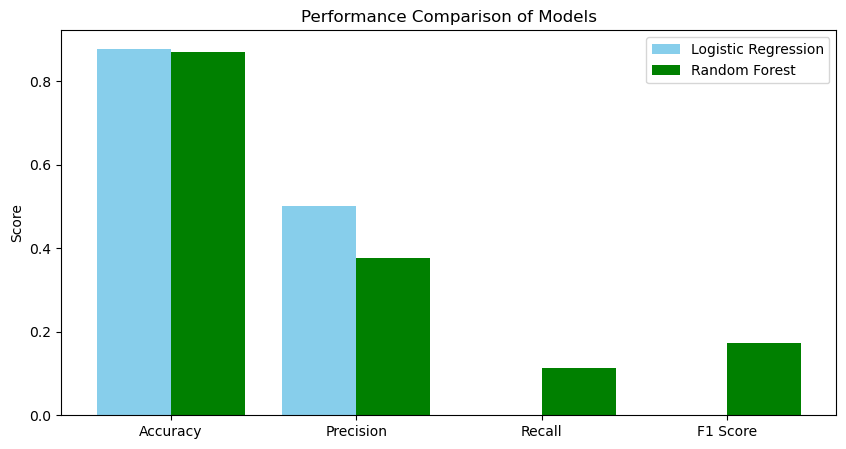

In [28]:


metrics = ['Accuracy','Precision','Recall','F1 Score']

lr = [
    accuracy_score(y_test, y_pred_lr),
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]

rf = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = np.arange(len(metrics))

plt.figure(figsize=(10,5))

plt.bar(x-0.2, lr, 0.4, label='Logistic Regression', color='skyblue')
plt.bar(x+0.2, rf, 0.4, label='Random Forest', color='green')

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison of Models")
plt.legend()

plt.show()